In [2]:
import numpy as np

In [ ]:
import mlx
import mlx.core as jnp

ModuleNotFoundError: No module named 'mlx.numpy'

In [ ]:
#@title Input protein sequence(s), then hit `Runtime` -> `Run all`

import os
import re
import hashlib
import random

from sys import version_info
python_version = f"{version_info.major}.{version_info.minor}"

def add_hash(x,y):
  return x+"_"+hashlib.sha1(y.encode()).hexdigest()[:5]

query_sequence = """MFVFLVLLPLVSSQCVNLTTRTQLPPAYTNSFTRGVYYPDKVFRSSVLHSTQDLFLPFFSNVTWFHAIHVSGTNGTKRFDN
LYFQPTNGVGYQPYRVVVLSFELLHAPATVCGPKKSTNLVKNKCVNFNFNGLTGTGVLTESNKKFLPFQQFGRDIADTTDA
VLTKEVNNYEPKYSCVKFGSGFRIFTGVNCKHTSPDLPQGFSALEPLVDLPIGINITRFQTLLALHRSYLTPGDSSSGWTAG
AAAYYVGYLQPRTFLGKYSKHTPINLVRDLPQGFSALEPLVDLPIGINITRFQTLLALHRSYLTPGDSSSGWTAGAAAYYVG
YLQPRTFLGKYSKHTPINLVRDLPQGFSALEPLVDLPIGINITRFQTLLALHRSYLTPGDSSSGWTAGAAAYYVGYLQPRTF
LGKYSKHTPINLVRDLPQGFSALEPLVDLPIGINITRFQTLLALHRSYLTPGDSSSGWTAGAAAYYVGYLQPRTFLGKYSKH
TPINLVRDLPQGFSALEPLVDLPIGINITRFQTLLALHRSYLTPGDSSSGWTAGAAAYYVGYLQPRTFLGKYSKHTPINLVQ
FDNPVLPFHGTQTLLALHRSYLTPGDSSSGWTAGAAAYYVGYLQPRTFLGKYSKHTPINLVRDLPQGFSALEPLVDLPIGIN
ITRFQTLLALHRSYLTPGDSSSGWTAGAAAYYVGYLQPRTFLGKYSKHTPINLVRDLPQGFSALEPLVDLPIGINITRFQTL
LALHRSYLTPGDSSSGWTAGAAAYYVGYLQPRTFLGKYSKHTPINLVRDLPQGFSALEPLVDLPIGINITRFQTLLALHRSY
LTPGDSSSGWTAGAAAYYVGYLQPRTFLGKYSKHTPINLVRDLPQGFSALEPLVDLPIGINITRFQTLLALHRSYLTPGDSS
SGWTAGAAAYYVGYLQPRTFLGKYSKHTPINLVRDLPQGFSALEPLVDLPIGINITRFQTLLALHRSYLTPGDSSSGWTAGA
AAYYVGYLQPRTFLGKYSKHTPINLVRDLPQGFSALEPLVDLPIGINITRFQTLLALHRSYLTPGDSSSGWTAGAAAYYVGY
LQPRTFLGKYSKHTPINLVRDLPQGFSALEPLVDLPIGINITRFQTLLALHRSYLTPGDSSSGWTAGAAAYYVGYLQPRTFL
GKYSKHTPINLVRDLPQGFSALEPLVDLPIGINITRFQTLLALHRSYLTPGDSSSGWTAGAAAYYVGYLQPRTFLGKYSKHT
PINLVRDLPQGFSALEPLVDLPIGINITRFQTLLALHRSYLTPGDSSSGWTAGAAAYYVGYLQPRTFLGKYSKHTPINLVRD
LPQGFSALEPLVDLPIGINITRFQTLLALHRSYLTPGDSSSGWTAGAAAYYVGYLQPRTFLGKYSKHTPINLVRDLPQGFSA
LEPLVDLPIGINITRFQTLLALHRSYLTPGDSSSGWTAGAAAYYVGYLQPRTFLGKYSKHTPINLVRDLPQGFSALEPLVDL
PIGINITRFQTLLALHRSYLTPGDSSSGWTAGAAAYYVGYLQPRTFLGKYSKHTPINLVRDLPQGFSALEPLVDLPIGINIT
RFQTLLALHRSYLTPGDSSSGWTAGAAAYYVGYLQPRTFLGKYSKHTPINLVRDLPQGFSALEPLVDLPIGINITRFQTLLA
LHRSYLTPGDSSSGWTAGAAAYYVGYLQPRTFLGKYSKHTPINLVRDLPQGFSALEPLVDLPIGINITRFQTLLALHRSYLT
PGDSSSGWTAGAAAYYVGYLQPRTFLGKYSKHTPINLVRDLPQGFSALEPLVDLPIGINITRFQTLLALHRSYLTPGDSSSG
WTAGAAAYYVGYLQPRTFLGKYSKHTPINLVRDLPQGFSALEPLVDLPIGINITRFQTLLALHRSYLTPGDSSSGWTAGAAA
YYVGYLQPRTFLGKYSKHTPINLVRDLPQGFSALEPLVDLPIGINITRFQTLLALHRSYLTPGDSSSGWTAGAAAYYVGYLQ
PRTFLGKYSKHTPINLVRDLPQGFSALEPLVDLPIGINITRFQTLLALHRSYLTPGDSSSGWTAGAAAYYVGYLQPRTFLGK
YSKHTPINLVRDLPQGFSALEPLVDLPIGINITRFQTLLALHRSYLTPGDSSSGWTAGAAAYYVGYLQPRTFLGKYSKHTPI
NLVRDLPQGFSALEPLVDLPIGINITRFQTLLALHRSYLTPGDSSSGWTAGAAAYYVGYLQPRTFLGKYSKHTPINLVRDLP
QGFSALEPLVDLPIGINITRFQTLLALHRSYLTPGDSSSGWTAGAAAYYVGYLQPRTFLGKYSKHTPINLVRDLPQGFSALEPL"""
# query_sequence = "MFVFLVLLPLVSSQCVNLTTRTQLPPAYTNSFTRGVYYPDKVFRSSVLHSTQDLFLPFFSNVTWFHAIHVSGTNGTKRFDNPVLPFNDGVYFASTEKSNIIRGWIFGTTLDSKTQSLLIVNNATNVVIKVCEFQFCNDPFLGVYYHKNNKSWMESGVYSSANNCTFEYVSQPFLMDLEGKQGNFKNLREFVFKNIDGYFKIYSKHTPINLVRDLPQGFSALEPLVDLPIGINITRFQTLLALHRSYLTPGDSSSGWTAGAAAYYVGYLQPRTFLLKYNENGTITDAVDCSQNPLAELKCSVKSFEIDKGIYQTSNFRVQPTESIVRFP"
# query_sequence = """MALLHSARVLSGVASAFHPGLAAAASARASSWWAHVEMGPPDPILGVTEAYKRDTNSKKMNLGVGAYRDD
# NGKPYVLPSVRKAEAQIAAKGLDKEYLPIGGLAEFCRASAELALGENSEVVKSGRFVTVQTISGTGALRI
# GASFLQRFFKFSRDVFLPKPSWGNHTPIFRDAGMQLQSYRYYDPKTCGFDFTGALEDISKIPEQSVLLLH
# ACAHNPTGVDPRPEQWKEIATVVKKRNLFAFFDMAYQGFASGDGDKDAWAVRHFIEQGINVCLCQSYAKN
# MGLYGERVGAFTVICKDADEAKRVESQLKILIRPMYSNPPIHGARIASTILTSPDLRKQWLQEVKGMADR
# IIGMRTQLVSNLKKEGSTHSWQHITDQIGMFCFTGLKPEQVERLTKEFSIYMTKDGRISVAGVTSGNVGY
# LAHAIHQVTK"""

query_sequence = 'PIAQIHILEGRSDEQKETLIREVSEAISRSLDAPLTSVRVIITEMAKGHFGIGGELASK'
# query_sequence = "MAKDIVLDRLKFGSGNSPKDLTEVGHSITKEKLFTVGRLTVVKGDRILRDKDTYRYHYTDGDCPIAYTSVPVQDVLIEV"
 #@param {type:"string"}
#@markdown  - Use `:` to specify inter-protein chainbreaks for **modeling complexes** (supports homo- and hetro-oligomers). For example **PI...SK:PI...SK** for a homodimer
# query_sequence = "GIVQCCTSI CSLYQLENYC"
jobname = 'test' #@param {type:"string"}
# number of models to use
num_relax = 0 #@param [0, 1, 5] {type:"raw"}
#@markdown - specify how many of the top ranked structures to relax using amber
template_mode = "none" #@param ["none", "pdb100","custom"]
#@markdown - `none` = no template information is used. `pdb100` = detect templates in pdb100 (see [notes](#pdb100)). `custom` - upload and search own templates (PDB or mmCIF format, see [notes](#custom_templates))

use_amber = num_relax > 0

# remove whitespaces
query_sequence = "".join(query_sequence.split())

basejobname = "".join(jobname.split())
basejobname = re.sub(r'\W+', '', basejobname)
jobname = add_hash(basejobname, query_sequence)

# check if directory with jobname exists
def check(folder):
  if os.path.exists(folder):
    return False
  else:
    return True
if not check(jobname):
  n = 0
  while not check(f"{jobname}_{n}"): n += 1
  jobname = f"{jobname}_{n}"

# make directory to save results
os.makedirs(jobname, exist_ok=True)

# save queries
queries_path = os.path.join(jobname, f"{jobname}.csv")
with open(queries_path, "w") as text_file:
  text_file.write(f"id,sequence\n{jobname},{query_sequence}")

if template_mode == "pdb100":
  use_templates = True
  custom_template_path = None
elif template_mode == "custom":
  custom_template_path = os.path.join(jobname,f"template")
  os.makedirs(custom_template_path, exist_ok=True)
  uploaded = files.upload()
  use_templates = True
  for fn in uploaded.keys():
    os.rename(fn,os.path.join(custom_template_path,fn))
else:
  custom_template_path = None
  use_templates = False

print("jobname",jobname)
print("sequence",query_sequence)
print("length",len(query_sequence.replace(":","")))



jobname test_a5e17_1
sequence PIAQIHILEGRSDEQKETLIREVSEAISRSLDAPLTSVRVIITEMAKGHFGIGGELASK
length 59


In [4]:

import os
USE_AMBER = use_amber
USE_TEMPLATES = use_templates
PYTHON_VERSION = python_version
os.system("ln -s /usr/local/lib/python3.*/dist-packages/colabfold colabfold")
os.system("ln -s /usr/local/lib/python3.*/dist-packages/alphafold alphafold")
os.system("touch COLABFOLD_READY")
if not os.path.isfile("COLABFOLD_READY"):
  print("installing colabfold...")
  os.system("pip install -q --no-warn-conflicts 'colabfold[alphafold-minus-jax] @ git+https://github.com/sokrypton/ColabFold'")
  if os.environ.get('TPU_NAME', False) != False:
    os.system("pip uninstall -y jax jaxlib")
    os.system("pip install --no-warn-conflicts --upgrade dm-haiku==0.0.10 'jax[cuda12_pip]'==0.3.25 -f https://storage.googleapis.com/jax-releases/jax_cuda_releases.html")
  os.system("ln -s /usr/local/lib/python3.*/dist-packages/colabfold colabfold")
  os.system("ln -s /usr/local/lib/python3.*/dist-packages/alphafold alphafold")
  os.system("touch COLABFOLD_READY")

if USE_AMBER or USE_TEMPLATES:
  if not os.path.isfile("CONDA_READY"):
    print("installing conda...")
    os.system("wget -qnc https://github.com/conda-forge/miniforge/releases/latest/download/Mambaforge-Linux-x86_64.sh")
    os.system("bash Mambaforge-Linux-x86_64.sh -bfp /usr/local")
    os.system("mamba config --set auto_update_conda false")
    os.system("touch CONDA_READY")

if USE_TEMPLATES and not os.path.isfile("HH_READY") and USE_AMBER and not os.path.isfile("AMBER_READY"):
  print("installing hhsuite and amber...")
  os.system(f"mamba install -y -c conda-forge -c bioconda kalign2=2.04 hhsuite=3.3.0 openmm=7.7.0 python='{PYTHON_VERSION}' pdbfixer")
  os.system("touch HH_READY")
  os.system("touch AMBER_READY")
else:
  if USE_TEMPLATES and not os.path.isfile("HH_READY"):
    print("installing hhsuite...")
    os.system(f"mamba install -y -c conda-forge -c bioconda kalign2=2.04 hhsuite=3.3.0 python='{PYTHON_VERSION}'")
    os.system("touch HH_READY")
  if USE_AMBER and not os.path.isfile("AMBER_READY"):
    print("installing amber...")
    os.system(f"mamba install -y -c conda-forge openmm=7.7.0 python='{PYTHON_VERSION}' pdbfixer")
    os.system("touch AMBER_READY")

ln: colabfold: File exists
ln: alphafold: File exists


In [5]:
#@markdown ### MSA options (custom MSA upload, single sequence, pairing mode)
msa_mode = "mmseqs2_uniref_env" #@param ["mmseqs2_uniref_env", "mmseqs2_uniref","single_sequence","custom"]
pair_mode = "unpaired_paired" #@param ["unpaired_paired","paired","unpaired"] {type:"string"}
#@markdown - "unpaired_paired" = pair sequences from same species + unpaired MSA, "unpaired" = seperate MSA for each chain, "paired" - only use paired sequences.

# decide which a3m to use
if "mmseqs2" in msa_mode:
  a3m_file = os.path.join(jobname,f"{jobname}.a3m")

elif msa_mode == "custom":
  a3m_file = os.path.join(jobname,f"{jobname}.custom.a3m")
  if not os.path.isfile(a3m_file):
    custom_msa_dict = files.upload()
    custom_msa = list(custom_msa_dict.keys())[0]
    header = 0
    import fileinput
    for line in fileinput.FileInput(custom_msa,inplace=1):
      if line.startswith(">"):
         header = header + 1
      if not line.rstrip():
        continue
      if line.startswith(">") == False and header == 1:
         query_sequence = line.rstrip()
      print(line, end='')

    os.rename(custom_msa, a3m_file)
    queries_path=a3m_file
    print(f"moving {custom_msa} to {a3m_file}")

else:
  a3m_file = os.path.join(jobname,f"{jobname}.single_sequence.a3m")
  with open(a3m_file, "w") as text_file:
    text_file.write(">1\n%s" % query_sequence)

In [6]:
#@markdown ### Advanced settings
model_type = "auto" #@param ["auto", "alphafold2_ptm", "alphafold2_multimer_v1", "alphafold2_multimer_v2", "alphafold2_multimer_v3", "deepfold_v1"]
#@markdown - if `auto` selected, will use `alphafold2_ptm` for monomer prediction and `alphafold2_multimer_v3` for complex prediction.
#@markdown Any of the mode_types can be used (regardless if input is monomer or complex).
num_recycles = "10" #@param ["auto", "0", "1", "3", "6", "12", "24", "48"]
#@markdown - if `auto` selected, will use `num_recycles=20` if `model_type=alphafold2_multimer_v3`, else `num_recycles=3` .
recycle_early_stop_tolerance = "auto" #@param ["auto", "0.0", "0.5", "1.0"]
#@markdown - if `auto` selected, will use `tol=0.5` if `model_type=alphafold2_multimer_v3` else `tol=0.0`.
relax_max_iterations = 200 #@param [0, 200, 2000] {type:"raw"}
#@markdown - max amber relax iterations, `0` = unlimited (AlphaFold2 default, can take very long)
pairing_strategy = "greedy" #@param ["greedy", "complete"] {type:"string"}
#@markdown - `greedy` = pair any taxonomically matching subsets, `complete` = all sequences have to match in one line.


#@markdown #### Sample settings
#@markdown -  enable dropouts and increase number of seeds to sample predictions from uncertainty of the model.
#@markdown -  decrease `max_msa` to increase uncertainity
max_msa = "auto" #@param ["auto", "512:1024", "256:512", "64:128", "32:64", "16:32"]
num_seeds = 1 #@param [1,2,4,8,16] {type:"raw"}
use_dropout = False #@param {type:"boolean"}

num_recycles = None if num_recycles == "auto" else int(num_recycles)
recycle_early_stop_tolerance = None if recycle_early_stop_tolerance == "auto" else float(recycle_early_stop_tolerance)
if max_msa == "auto": max_msa = None

#@markdown #### Save settings
save_all = False #@param {type:"boolean"}
save_recycles = False #@param {type:"boolean"}
save_to_google_drive = False #@param {type:"boolean"}
#@markdown -  if the save_to_google_drive option was selected, the result zip will be uploaded to your Google Drive
dpi = 200 #@param {type:"integer"}
#@markdown - set dpi for image resolution

if save_to_google_drive:
  from pydrive2.drive import GoogleDrive
  from pydrive2.auth import GoogleAuth
  from google.colab import auth
  from oauth2client.client import GoogleCredentials
  auth.authenticate_user()
  gauth = GoogleAuth()
  gauth.credentials = GoogleCredentials.get_application_default()
  drive = GoogleDrive(gauth)
  print("You are logged into Google Drive and are good to go!")

#@markdown Don't forget to hit `Runtime` -> `Run all` after updating the form.

In [7]:
#@title Run Prediction
display_images = True #@param {type:"boolean"}

import sys
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
from Bio import BiopythonDeprecationWarning
warnings.simplefilter(action='ignore', category=BiopythonDeprecationWarning)
from pathlib import Path
from colabfold.download import download_alphafold_params, default_data_dir
from colabfold.utils import setup_logging
from colabfold.batch import get_queries, run, set_model_type
from colabfold.plot import plot_msa_v2

import os
import numpy as np

try:
  K80_chk = os.popen('nvidia-smi | grep "Tesla K80" | wc -l').read()
except:
  K80_chk = "0"
  pass
if "1" in K80_chk:
  print("WARNING: found GPU Tesla K80: limited to total length < 1000")
  if "TF_FORCE_UNIFIED_MEMORY" in os.environ:
    del os.environ["TF_FORCE_UNIFIED_MEMORY"]
    
  if "XLA_PYTHON_CLIENT_MEM_FRACTION" in os.environ:
    del os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"]
from colabfold.colabfold import plot_protein
from pathlib import Path
import matplotlib.pyplot as plt
if use_amber and f"/usr/local/lib/python{python_version}/site-packages/" not in sys.path:
  sys.path.insert(0, f"/usr/local/lib/python{python_version}/site-packages/")
def input_features_callback(input_features):
  if display_images:
    plot_msa_v2(input_features)
    plt.show()
    plt.close()
def prediction_callback(protein_obj, length,
                        prediction_result, input_features, mode):
  model_name, relaxed = mode
  if not relaxed:
    if display_images:
      fig = plot_protein(protein_obj, Ls=length, dpi=150)
      plt.show()
      plt.close()
result_dir = jobname
log_filename = os.path.join(jobname,"log.txt")
setup_logging(Path(log_filename))

queries, is_complex = get_queries(queries_path)
model_type = set_model_type(is_complex, model_type)

if "multimer" in model_type and max_msa is not None:
  use_cluster_profile = False
else:
  use_cluster_profile = True

/bin/sh: nvidia-smi: command not found


In [8]:

try:
  K80_chk = os.popen('nvidia-smi | grep "Tesla K80" | wc -l').read()
except:
  K80_chk = "0"
  pass
if "1" in K80_chk:
  print("WARNING: found GPU Tesla K80: limited to total length < 1000")
  if "TF_FORCE_UNIFIED_MEMORY" in os.environ:
    del os.environ["TF_FORCE_UNIFIED_MEMORY"]
  if "XLA_PYTHON_CLIENT_MEM_FRACTION" in os.environ:
    del os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"]

from colabfold.colabfold import plot_protein
from pathlib import Path
import matplotlib.pyplot as plt

# For some reason we need that to get pdbfixer to import
if use_amber and f"/usr/local/lib/python{python_version}/site-packages/" not in sys.path:
    sys.path.insert(0, f"/usr/local/lib/python{python_version}/site-packages/")

def input_features_callback(input_features):
  if display_images:
    plot_msa_v2(input_features)
    plt.show()
    plt.close()

def prediction_callback(protein_obj, length,
                        prediction_result, input_features, mode):
  model_name, relaxed = mode
  if not relaxed:
    if display_images:
      fig = plot_protein(protein_obj, Ls=length, dpi=150)
      plt.show()
      plt.close()

result_dir = jobname
log_filename = os.path.join(jobname,"log.txt")
setup_logging(Path(log_filename))

queries, is_complex = get_queries(queries_path)
model_type = set_model_type(is_complex, model_type)

if "multimer" in model_type and max_msa is not None:
  use_cluster_profile = False
else:
  use_cluster_profile = True

# download_alphafold_params(model_type, Path("."))


/bin/sh: nvidia-smi: command not found


W0000 00:00:1752763181.317633 16277217 mps_client.cc:510] WARNING: JAX Apple GPU support is experimental and not all JAX functionality is correctly supported!
I0000 00:00:1752763181.329711 16277217 service.cc:145] XLA service 0x14ca0e480 initialized for platform METAL (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1752763181.329725 16277217 service.cc:153]   StreamExecutor device (0): Metal, <undefined>
I0000 00:00:1752763181.330787 16277217 mps_client.cc:406] Using Simple allocator.
I0000 00:00:1752763181.330796 16277217 mps_client.cc:384] XLA backend will use up to 51539132416 bytes on device 0 for SimpleAllocator.


Metal device set to: Apple M4 Max

systemMemory: 64.00 GB
maxCacheSize: 24.00 GB

2025-07-17 20:09:42,702 Running on GPU
2025-07-17 20:09:42,753 Found 5 citations for tools or databases
2025-07-17 20:09:42,753 Query 1/1: test_a5e17_1 (length 59)


COMPLETE: 100%|██████████| 150/150 [elapsed: 00:08 remaining: 00:00]


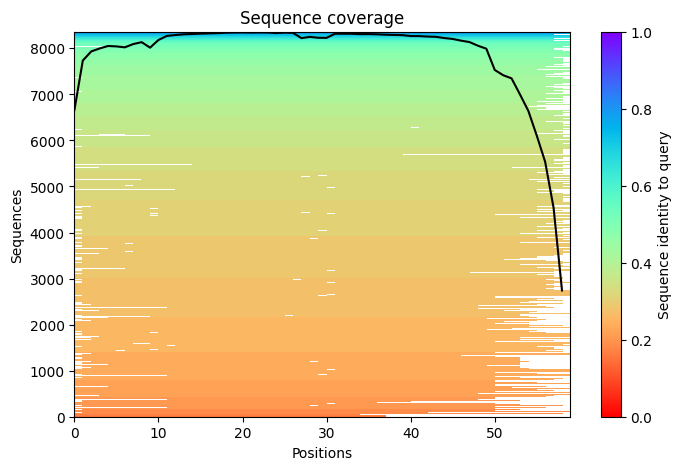

2025-07-17 20:09:51,392 Setting max_seq=512, max_extra_seq=5120
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: `haiku.experimental.flax` features require `flax` to be installed.
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert


I0000 00:00:1752763193.027230 16277217 mlir_graph_optimization_pass.cc:425] MLIR V1 optimization pass is not enabled


2025-07-17 20:10:06,564 alphafold2_ptm_model_1_seed_000 recycle=0 pLDDT=96.6 pTM=0.754


/opt/miniconda3/envs/Vriti/lib/python3.11/site-packages/jax/_src/array.py:407: RuntimeWarning: overflow encountered in cast
  return np.asarray(self._value, dtype=dtype, **kwds)


2025-07-17 20:10:18,361 alphafold2_ptm_model_1_seed_000 recycle=1 pLDDT=96.6 pTM=0.758 tol=0.313
2025-07-17 20:10:18,362 alphafold2_ptm_model_1_seed_000 took 25.1s (1 recycles)


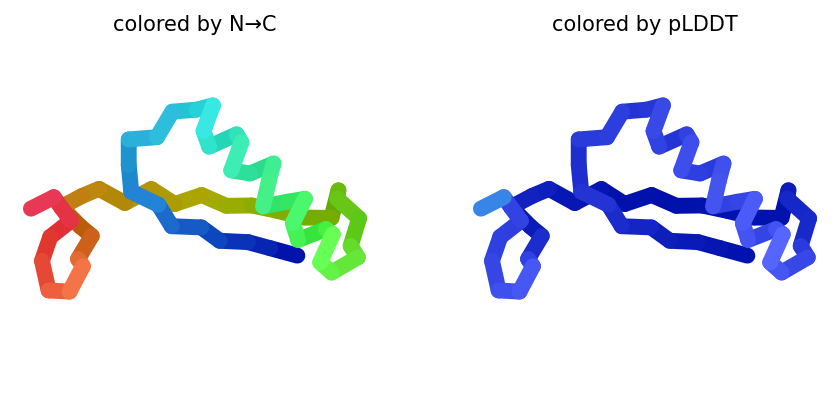

2025-07-17 20:10:18,385 reranking models by 'plddt' metric
2025-07-17 20:10:18,385 rank_001_alphafold2_ptm_model_1_seed_000 pLDDT=96.6 pTM=0.758
2025-07-17 20:10:18,480 Done
  adding: test_a5e17_1/ (stored 0%)
  adding: test_a5e17_1/test_a5e17_1.a3m (deflated 63%)
  adding: test_a5e17_1/test_a5e17_1.done.txt (stored 0%)
  adding: test_a5e17_1/test_a5e17_1_unrelaxed_rank_001_alphafold2_ptm_model_1_seed_000.pdb (deflated 78%)
  adding: test_a5e17_1/test_a5e17_1_env/ (stored 0%)
  adding: test_a5e17_1/test_a5e17_1_env/bfd.mgnify30.metaeuk30.smag30.a3m (deflated 59%)
  adding: test_a5e17_1/test_a5e17_1_env/msa.sh (deflated 74%)
  adding: test_a5e17_1/test_a5e17_1_env/out.tar.gz (deflated 0%)
  adding: test_a5e17_1/test_a5e17_1_env/pdb70.m8 (deflated 66%)
  adding: test_a5e17_1/test_a5e17_1_env/uniref.a3m (deflated 66%)
  adding: test_a5e17_1/config.json (deflated 55%)
  adding: test_a5e17_1/test_a5e17_1_coverage.png (deflated 8%)
  adding: test_a5e17_1/test_a5e17_1_plddt.png (deflated 15%)

0

In [9]:
results = run(
    queries=queries,
    result_dir=result_dir,
    use_templates=use_templates,
    custom_template_path=custom_template_path,
    num_relax=num_relax,
    msa_mode=msa_mode,
    model_type=model_type,
    num_models=1,
    num_recycles=1,
    relax_max_iterations=relax_max_iterations,
    recycle_early_stop_tolerance=recycle_early_stop_tolerance,
    num_seeds=num_seeds,
    use_dropout=use_dropout,
    model_order=[1],
    is_complex=is_complex,
    data_dir=Path("."),
    keep_existing_results=False,
    rank_by="auto",
    pair_mode=pair_mode,
    pairing_strategy=pairing_strategy,
    stop_at_score=float(100),
    prediction_callback=prediction_callback,
    dpi=dpi,
    zip_results=False,
    save_all=save_all,
    max_msa=max_msa,
    use_cluster_profile=use_cluster_profile,
    input_features_callback=input_features_callback,
    save_recycles=save_recycles,
    user_agent="colabfold/google-colab-main",
)
results_zip = f"{jobname}.result.zip"
os.system(f"zip -r {results_zip} {jobname}")

In [1]:
import jax
print(jax.devices())


Platform 'METAL' is experimental and not all JAX functionality may be correctly supported!


Metal device set to: Apple M4 Max

systemMemory: 64.00 GB
maxCacheSize: 24.00 GB

[METAL(id=0)]


W0000 00:00:1752765187.217008 16286418 mps_client.cc:510] WARNING: JAX Apple GPU support is experimental and not all JAX functionality is correctly supported!
I0000 00:00:1752765187.225425 16286418 service.cc:145] XLA service 0x114504440 initialized for platform METAL (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1752765187.225436 16286418 service.cc:153]   StreamExecutor device (0): Metal, <undefined>
I0000 00:00:1752765187.226579 16286418 mps_client.cc:406] Using Simple allocator.
I0000 00:00:1752765187.226587 16286418 mps_client.cc:384] XLA backend will use up to 51539132416 bytes on device 0 for SimpleAllocator.


In [10]:
#@title Display 3D structure {run: "auto"}
import py3Dmol
import glob
import matplotlib.pyplot as plt
from colabfold.colabfold import plot_plddt_legend
from colabfold.colabfold import pymol_color_list, alphabet_list
rank_num = 1 #@param ["1", "2", "3", "4", "5"] {type:"raw"}
color = "lDDT" #@param ["chain", "lDDT", "rainbow"]
show_sidechains = True #@param {type:"boolean"}
show_mainchains = False #@param {type:"boolean"}

tag = results["rank"][0][rank_num - 1]
jobname_prefix = ".custom" if msa_mode == "custom" else ""
pdb_filename = f"{jobname}/{jobname}{jobname_prefix}_unrelaxed_{tag}.pdb"
pdb_file = glob.glob(pdb_filename)

def show_pdb(rank_num=1, show_sidechains=False, show_mainchains=False, color="lDDT"):
  model_name = f"rank_{rank_num}"
  view = py3Dmol.view(js='https://3dmol.org/build/3Dmol.js',)
  view.addModel(open(pdb_file[0],'r').read(),'pdb')

  if color == "lDDT":
    view.setStyle({'cartoon': {'colorscheme': {'prop':'b','gradient': 'roygb','min':50,'max':90}}})
  elif color == "rainbow":
    view.setStyle({'cartoon': {'color':'spectrum'}})
  elif color == "chain":
    chains = len(queries[0][1]) + 1 if is_complex else 1
    for n,chain,color in zip(range(chains),alphabet_list,pymol_color_list):
       view.setStyle({'chain':chain},{'cartoon': {'color':color}})

  if show_sidechains:
    BB = ['C','O','N']
    view.addStyle({'and':[{'resn':["GLY","PRO"],'invert':True},{'atom':BB,'invert':True}]},
                        {'stick':{'colorscheme':f"WhiteCarbon",'radius':0.3}})
    view.addStyle({'and':[{'resn':"GLY"},{'atom':'CA'}]},
                        {'sphere':{'colorscheme':f"WhiteCarbon",'radius':0.3}})
    view.addStyle({'and':[{'resn':"PRO"},{'atom':['C','O'],'invert':True}]},
                        {'stick':{'colorscheme':f"WhiteCarbon",'radius':0.3}})
  if show_mainchains:
    BB = ['C','O','N','CA']
    view.addStyle({'atom':BB},{'stick':{'colorscheme':f"WhiteCarbon",'radius':0.3}})

  view.zoomTo()
  return view

show_pdb(rank_num, show_sidechains, show_mainchains, color).show()
# if color == "lDDT":
  # plot_plddt_legend().show()

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [11]:
results

{'rank': [['rank_001_alphafold2_ptm_model_1_seed_000']],
 'metric': [[{'mean_plddt': 96.5625,
    'ptm': 0.75830078125,
    'print_line': ' pLDDT=96.6 pTM=0.758'}]]}

In [12]:
pip install xelatex

/opt/miniconda3/envs/Vriti/lib/python3.11/pty.py:89: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  pid, fd = os.forkpty()


ERROR: Could not find a version that satisfies the requirement xelatex (from versions: none)
ERROR: No matching distribution found for xelatex
Note: you may need to restart the kernel to use updated packages.


In [13]:
import tensorflow as tf

cifar = tf.keras.datasets.cifar100
(x_train, y_train), (x_test, y_test) = cifar.load_data()
model = tf.keras.applications.ResNet50(
    include_top=True,
    weights=None,
    input_shape=(32, 32, 3),
    classes=100,)

loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False)
model.compile(optimizer="adam", loss=loss_fn, metrics=["accuracy"])
model.fit(x_train, y_train, epochs=5, batch_size=64)

 53690368/169001437 ━━━━━━━━━━━━━━━━━━━━ 56s 0us/step

KeyboardInterrupt: 

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
X = np.arange(-40, 40, (80/8000))
Y = np.sin(X)

In [ ]:
def FourierTransform(X, Y, freq):
    result = 0
    for i in range(1, len(X)):
        result += Y[i] * np.sin(2 * np.pi * freq * X[i]) * (X[i]-X[i-1])
    return result

In [ ]:
Yfreq = np.array([FourierTransform(X, Y, i) for i in X])

In [ ]:
fig = plt.subplot()
fig.plot(X, Yfreq)

In [ ]:
Y2 = np.fft.fft(Y)

In [ ]:
plot = plt.subplot()
plot.plot(X, Y2)

In [2]:
import mlx.core

In [4]:
A = mlx.core.array([1, 2, 3, 4, 5])

In [ ]:
def f(x):
    return x*x

In [6]:
f_ = mlx.core.grad(f)

In [7]:
f(A)

array([1, 4, 9, 16, 25], dtype=int32)

In [18]:
mlx.core.vmap(f_)(A)

array([2, 4, 6, 8, 10], dtype=int32)